# PolyAtlas — Notebook 05h: CDR-Only Variant of Feature Climb

**Project:** Cross-Campaign Polyreactivity Atlas  
**Notebook:** `PolyAtlas_05h_cdr_only_climb`  
**Version:** `v0.1.0`  
**Date:** 2026-04-21

## Purpose

Notebook 05g reached test AUROC 0.8359 with 16 features on NbBench PolyRx, beating 9 of 11 language models. However, the selected feature set includes full-sequence features (`full_arom`, `full_len`, `full_abs_charge`, `full_charge`, `H1_hphob_frac`, `H2_hphob`) that span framework regions. Since NbBench PolyRx is built from synthetic VHH libraries with shared framework design, full-sequence features may partially reflect library-specific framework composition that doesn't transfer to novel libraries.

This notebook tests transferability by running forward selection on restricted feature catalogs:

1. **CDR-only variant:** H1 + H2 + H3 features only (no `full_*` features). Expected transfer to any VHH library with a different framework design.
2. **CDR-H3-only variant:** H3 features only. Most conservative; tests the 'just the loop' extreme.
3. **Full reference:** All 52 features (replicates 05g) for comparison.

## Interpretation framework

If CDR-only AUROC is close to full-feature AUROC (within ~0.01), the full-feature result is library-transferable and the framework caveat is weak.

If CDR-only AUROC drops substantially (0.02+), a meaningful share of the full-feature signal is framework composition, which would be library-dependent, and the paper should report both numbers with clear framing.

If CDR-H3-only is surprisingly strong, we have a simpler pitch: 'CDR-H3 features alone reach X AUROC.'

## Protocol

Identical to 05g except for feature catalog restriction:
- Train n=101,673 for fitting
- Val n=14,576 for feature selection
- Test n=24,955 for final evaluation
- Forward selection: MIN_GAIN=0.0005, min 10 steps, max 25 features
- LR with class_weight='balanced', standardized features

## Runtime

~15-25 minutes total. Three climbs, each similar cost to 05g.

In [ ]:
from IPython.display import display, Javascript
display(Javascript('''
function ClickConnect(){
    const selectors = ["#top-toolbar > colab-connect-button", "colab-connect-button", "#connect"];
    for (const sel of selectors) {
        const el = document.querySelector(sel);
        if (el) { if (el.shadowRoot) { const inner = el.shadowRoot.querySelector("#connect"); if (inner) { inner.click(); return; } } el.click(); return; }
    }
}
setInterval(ClickConnect, 60000);
'''))

from google.colab import drive
from pathlib import Path
import json

drive.mount('/content/drive', force_remount=True)

DRIVE_ROOT = Path('/content/drive/MyDrive/PolyAtlas')
NOTEBOOK_NAME = "PolyAtlas_05h_cdr_only_climb"
PROJECT_VERSION = "0.1.0"
DRIVE_OUTPUT = DRIVE_ROOT / f"{NOTEBOOK_NAME}_v{PROJECT_VERSION}"
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {DRIVE_OUTPUT}")

<IPython.core.display.Javascript object>

Mounted at /content/drive
Output dir: /content/drive/MyDrive/PolyAtlas/PolyAtlas_05h_cdr_only_climb_v0.1.0


In [ ]:
!pip install -q datasets scikit-learn

In [ ]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

ds = load_dataset('ZYMScott/polyreaction')
train_df = ds['train'].to_pandas()
val_df = ds['validation'].to_pandas()
test_df = ds['test'].to_pandas()

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/101854 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/14613 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25007 [00:00<?, ? examples/s]

Train: (101854, 5), Val: (14613, 5), Test: (25007, 5)


## §1. Feature catalog (identical definitions to 05g)

In [ ]:
KYTE_DOOLITTLE = {'A': 1.8,'C': 2.5,'D':-3.5,'E':-3.5,'F': 2.8,'G':-0.4,'H':-3.2,'I': 4.5,'K':-3.9,
                   'L': 3.8,'M': 1.9,'N':-3.5,'P':-1.6,'Q':-3.5,'R':-4.5,'S':-0.8,'T':-0.7,'V': 4.2,
                   'W':-0.9,'Y':-1.3}
CHARGE_AT_PH74 = {'D':-1,'E':-1,'K':+1,'R':+1,'H':+0.1}
AROMATIC = set('FWY')
POSITIVE = set('KR')
NEGATIVE = set('DE')
HYDROPHOBIC = set('ILVFMWYC')
PKA = {'C_term': 3.55, 'D': 4.05, 'E': 4.45, 'H': 5.98, 'K': 10.0, 'R': 12.0, 'Y': 10.0, 'C': 9.0, 'N_term': 8.0}

def net_charge(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return sum(CHARGE_AT_PH74.get(a, 0) for a in seq.upper())

def frac(seq, subset):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    s = seq.upper()
    return sum(1 for a in s if a in subset) / len(s)

def frac_residue(seq, residue):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return seq.upper().count(residue) / len(seq)

def mean_hydrophobicity(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return np.mean([KYTE_DOOLITTLE.get(a, 0) for a in seq.upper()])

def max_hydrophobic_run(seq):
    if not isinstance(seq, str) or len(seq) == 0: return 0
    s = seq.upper()
    best, cur = 0, 0
    for a in s:
        if a in HYDROPHOBIC:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best

def charge_dipole(seq):
    if not isinstance(seq, str) or len(seq) < 4: return 0
    mid = len(seq) // 2
    nterm_charge = net_charge(seq[:mid])
    cterm_charge = net_charge(seq[mid:])
    return nterm_charge - cterm_charge

def estimate_pI(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    s = seq.upper()
    def charge_at_ph(ph):
        c = 0
        c += 1 / (1 + 10**(ph - PKA['N_term']))
        c -= 1 / (1 + 10**(PKA['C_term'] - ph))
        for a in s:
            if a in ('K', 'R'):
                c += 1 / (1 + 10**(ph - PKA[a]))
            elif a in ('D', 'E'):
                c -= 1 / (1 + 10**(PKA[a] - ph))
            elif a == 'H':
                c += 1 / (1 + 10**(ph - PKA['H']))
            elif a == 'Y':
                c -= 1 / (1 + 10**(PKA['Y'] - ph))
            elif a == 'C':
                c -= 1 / (1 + 10**(PKA['C'] - ph))
        return c
    lo, hi = 0.0, 14.0
    for _ in range(50):
        mid = (lo + hi) / 2
        if charge_at_ph(mid) > 0:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

def build_features(df):
    feats = pd.DataFrame(index=df.index)
    for region, col in [('H1', 'CDR1_nogaps'), ('H2', 'CDR2_nogaps'),
                          ('H3', 'CDR3_nogaps'), ('full', 'seq')]:
        seqs = df[col].fillna('').astype(str)
        feats[f'{region}_len']       = seqs.str.len()
        feats[f'{region}_charge']    = seqs.apply(net_charge)
        feats[f'{region}_abs_charge'] = feats[f'{region}_charge'].abs()
        feats[f'{region}_pos_frac']  = seqs.apply(lambda s: frac(s, POSITIVE))
        feats[f'{region}_neg_frac']  = seqs.apply(lambda s: frac(s, NEGATIVE))
        feats[f'{region}_hphob']     = seqs.apply(mean_hydrophobicity)
        feats[f'{region}_hphob_frac'] = seqs.apply(lambda s: frac(s, HYDROPHOBIC))
        feats[f'{region}_arom']      = seqs.apply(lambda s: frac(s, AROMATIC))
        feats[f'{region}_W']         = seqs.apply(lambda s: frac_residue(s, 'W'))
        feats[f'{region}_R']         = seqs.apply(lambda s: frac_residue(s, 'R'))
        feats[f'{region}_V']         = seqs.apply(lambda s: frac_residue(s, 'V'))
        feats[f'{region}_G']         = seqs.apply(lambda s: frac_residue(s, 'G'))
    feats['H3_charge_dipole']     = df['CDR3_nogaps'].fillna('').astype(str).apply(charge_dipole)
    feats['H3_max_hphob_run']     = df['CDR3_nogaps'].fillna('').astype(str).apply(max_hydrophobic_run)
    feats['H3_pI']                = df['CDR3_nogaps'].fillna('').astype(str).apply(estimate_pI)
    feats['full_pI']              = df['seq'].fillna('').astype(str).apply(estimate_pI)
    return feats.fillna(0)

print("Computing features on train...")
X_train_full = build_features(train_df)
print("Computing features on val...")
X_val_full = build_features(val_df)
print("Computing features on test...")
X_test_full = build_features(test_df)

y_train = train_df['label'].astype(int).values
y_val = val_df['label'].astype(int).values
y_test = test_df['label'].astype(int).values

train_keep = X_train_full['H3_len'] > 0
val_keep = X_val_full['H3_len'] > 0
test_keep = X_test_full['H3_len'] > 0

X_train_full = X_train_full[train_keep].reset_index(drop=True)
y_train = y_train[train_keep.values]
X_val_full = X_val_full[val_keep].reset_index(drop=True)
y_val = y_val[val_keep.values]
X_test_full = X_test_full[test_keep].reset_index(drop=True)
y_test = y_test[test_keep.values]

all_features = list(X_train_full.columns)
print()
print(f"Cleaned: train n={len(X_train_full)}, val n={len(X_val_full)}, test n={len(X_test_full)}")
print(f"All features ({len(all_features)}): ready for restriction")

Computing features on train...
Computing features on val...
Computing features on test...

Cleaned: train n=101673, val n=14576, test n=24955
All features (52): ready for restriction


## §2. Define three variant feature catalogs

In [ ]:
full_feature_set = all_features  # 52 features, same as 05g
cdr_feature_set = [f for f in all_features if not f.startswith('full_')]  # no full_* features
h3_feature_set  = [f for f in all_features if f.startswith('H3_')]

variants = {
    'full (52 feats)':  full_feature_set,
    'CDR-only':          cdr_feature_set,
    'CDR-H3-only':       h3_feature_set,
}

print("Variants:")
for name, feats in variants.items():
    print(f"  {name}: {len(feats)} features")
print()
print("CDR-H3-only feature list:")
print(f"  {h3_feature_set}")
print()
print("CDR-only (H1+H2+H3) feature list sample:")
print(f"  First 10: {cdr_feature_set[:10]}")
print(f"  Count: {len(cdr_feature_set)}")

Variants:
  full (52 feats): 52 features
  CDR-only: 39 features
  CDR-H3-only: 15 features

CDR-H3-only feature list:
  ['H3_len', 'H3_charge', 'H3_abs_charge', 'H3_pos_frac', 'H3_neg_frac', 'H3_hphob', 'H3_hphob_frac', 'H3_arom', 'H3_W', 'H3_R', 'H3_V', 'H3_G', 'H3_charge_dipole', 'H3_max_hphob_run', 'H3_pI']

CDR-only (H1+H2+H3) feature list sample:
  First 10: ['H1_len', 'H1_charge', 'H1_abs_charge', 'H1_pos_frac', 'H1_neg_frac', 'H1_hphob', 'H1_hphob_frac', 'H1_arom', 'H1_W', 'H1_R']
  Count: 39


## §3. Forward selection routine (reusable)

In [ ]:
MAX_FEATURES = 25
MIN_GAIN = 0.0005
MIN_STEPS_BEFORE_STOP = 10

def run_forward_selection(candidate_features, seed_feature='H3_charge', tag=''):
    """Run greedy forward selection starting from seed_feature over candidate_features."""
    selected = [seed_feature] if seed_feature in candidate_features else [candidate_features[0]]
    remaining = [f for f in candidate_features if f != selected[0]]

    scaler = StandardScaler().fit(X_train_full[selected].values)
    lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=200)
    lr.fit(scaler.transform(X_train_full[selected].values), y_train)
    initial_val_auc = roc_auc_score(y_val, lr.predict_proba(scaler.transform(X_val_full[selected].values))[:, 1])

    climb_history = [{'step': 0, 'added_feature': selected[0], 'n_features': 1,
                       'val_AUROC': initial_val_auc, 'gain': initial_val_auc}]
    print(f"[{tag}] Step 0: {selected[0]} alone, val AUROC = {initial_val_auc:.4f}")

    step = 0
    while len(selected) < MAX_FEATURES and len(remaining) > 0:
        step += 1
        best_gain = -np.inf
        best_feat = None
        best_auc = None
        for cand in remaining:
            trial_set = selected + [cand]
            sc = StandardScaler().fit(X_train_full[trial_set].values)
            lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=200)
            lr.fit(sc.transform(X_train_full[trial_set].values), y_train)
            val_auc = roc_auc_score(y_val, lr.predict_proba(sc.transform(X_val_full[trial_set].values))[:, 1])
            gain = val_auc - climb_history[-1]['val_AUROC']
            if gain > best_gain:
                best_gain = gain
                best_feat = cand
                best_auc = val_auc
        climb_history.append({'step': step, 'added_feature': best_feat, 'n_features': len(selected) + 1,
                               'val_AUROC': best_auc, 'gain': best_gain})
        print(f"[{tag}] Step {step:2d}: + {best_feat:<22} val AUROC = {best_auc:.4f}  (gain {best_gain:+.4f})")
        selected.append(best_feat)
        remaining.remove(best_feat)
        if best_gain < MIN_GAIN and step >= MIN_STEPS_BEFORE_STOP:
            print(f"[{tag}] Stopping at step {step}: gain {best_gain:.4f} < {MIN_GAIN}")
            break

    climb_df = pd.DataFrame(climb_history)

    # Compute test AUROC at each step
    test_aucs = []
    for i in range(len(selected)):
        feat_set = selected[:i+1]
        sc = StandardScaler().fit(X_train_full[feat_set].values)
        lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
        lr.fit(sc.transform(X_train_full[feat_set].values), y_train)
        test_score = lr.predict_proba(sc.transform(X_test_full[feat_set].values))[:, 1]
        test_aucs.append(roc_auc_score(y_test, test_score))
    climb_df['test_AUROC'] = test_aucs
    climb_df['val_test_gap'] = climb_df['val_AUROC'] - climb_df['test_AUROC']

    return selected, climb_df

## §4. Run all three variants

In [ ]:
all_results = {}

for tag, feature_pool in variants.items():
    print(f"\n{'=' * 75}")
    print(f"VARIANT: {tag} (candidate pool size = {len(feature_pool)})")
    print(f"{'=' * 75}")
    selected, climb_df = run_forward_selection(feature_pool, seed_feature='H3_charge', tag=tag)
    all_results[tag] = {'selected': selected, 'climb_df': climb_df}
    climb_df.to_csv(DRIVE_OUTPUT / f'climb_{tag.replace(" ", "_").replace("(", "").replace(")", "")}.csv', index=False)


VARIANT: full (52 feats) (candidate pool size = 52)
[full (52 feats)] Step 0: H3_charge alone, val AUROC = 0.7261
[full (52 feats)] Step  1: + H2_charge              val AUROC = 0.7983  (gain +0.0722)
[full (52 feats)] Step  2: + H1_charge              val AUROC = 0.8081  (gain +0.0098)
[full (52 feats)] Step  3: + full_arom              val AUROC = 0.8158  (gain +0.0076)
[full (52 feats)] Step  4: + H3_len                 val AUROC = 0.8244  (gain +0.0086)
[full (52 feats)] Step  5: + full_len               val AUROC = 0.8284  (gain +0.0040)
[full (52 feats)] Step  6: + H2_hphob_frac          val AUROC = 0.8304  (gain +0.0020)
[full (52 feats)] Step  7: + H3_neg_frac            val AUROC = 0.8313  (gain +0.0010)
[full (52 feats)] Step  8: + H3_R                   val AUROC = 0.8343  (gain +0.0030)
[full (52 feats)] Step  9: + H3_abs_charge          val AUROC = 0.8356  (gain +0.0013)
[full (52 feats)] Step 10: + H3_charge_dipole       val AUROC = 0.8365  (gain +0.0009)
[full (52 feats

## §5. Final test evaluation + bootstrap for each variant

In [ ]:
B_BOOT = 500
final_results = {}

for tag, res in all_results.items():
    selected = res['selected']
    climb_df = res['climb_df']

    final_scaler = StandardScaler().fit(X_train_full[selected].values)
    final_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
    final_lr.fit(final_scaler.transform(X_train_full[selected].values), y_train)
    test_scores = final_lr.predict_proba(final_scaler.transform(X_test_full[selected].values))[:, 1]
    auc = roc_auc_score(y_test, test_scores)
    auprc = average_precision_score(y_test, test_scores)

    rng = np.random.RandomState(42)
    n_test = len(y_test)
    boot_aucs = []
    for b in range(B_BOOT):
        idx = rng.choice(n_test, size=n_test, replace=True)
        try:
            boot_aucs.append(roc_auc_score(y_test[idx], test_scores[idx]))
        except ValueError:
            pass
    boot_aucs = np.array(boot_aucs)

    final_results[tag] = {
        'selected': selected,
        'n_features': len(selected),
        'test_AUROC': float(auc),
        'test_AUPRC': float(auprc),
        'test_AUROC_95ci': [float(np.percentile(boot_aucs, 2.5)), float(np.percentile(boot_aucs, 97.5))],
        'coefficients': {feat: float(c) for feat, c in zip(selected, final_lr.coef_[0])},
    }

print("=" * 80)
print("FINAL TEST-SET PERFORMANCE BY VARIANT")
print("=" * 80)
for tag, res in final_results.items():
    ci_lo, ci_hi = res['test_AUROC_95ci']
    print(f"\n{tag}:")
    print(f"  Features ({res['n_features']}): {res['selected']}")
    print(f"  Test AUROC: {res['test_AUROC']:.4f}   95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"  Test AUPRC: {res['test_AUPRC']:.4f}")

FINAL TEST-SET PERFORMANCE BY VARIANT

full (52 feats):
  Features (16): ['H3_charge', 'H2_charge', 'H1_charge', 'full_arom', 'H3_len', 'full_len', 'H2_hphob_frac', 'H3_neg_frac', 'H3_R', 'H3_abs_charge', 'H3_charge_dipole', 'full_abs_charge', 'full_charge', 'H1_len', 'H1_hphob_frac', 'H2_hphob']
  Test AUROC: 0.8359   95% CI [0.8308, 0.8410]
  Test AUPRC: 0.8387

CDR-only:
  Features (13): ['H3_charge', 'H2_charge', 'H1_charge', 'H2_len', 'H3_len', 'H1_arom', 'H3_arom', 'H3_neg_frac', 'H3_R', 'H3_abs_charge', 'H2_hphob_frac', 'H3_charge_dipole', 'H1_hphob']
  Test AUROC: 0.8336   95% CI [0.8281, 0.8389]
  Test AUPRC: 0.8364

CDR-H3-only:
  Features (11): ['H3_charge', 'H3_len', 'H3_neg_frac', 'H3_R', 'H3_charge_dipole', 'H3_arom', 'H3_hphob_frac', 'H3_W', 'H3_hphob', 'H3_abs_charge', 'H3_max_hphob_run']
  Test AUROC: 0.7538   95% CI [0.7476, 0.7600]
  Test AUPRC: 0.7604


## §6. Comparison with NbBench Table 10 (all three variants included)

In [ ]:
nbbench_table10 = {
    'ProtBert':        0.837,
    'ESM-2 (150M)':    0.833,
    'ESM-2 (650M)':    0.842,
    'AbLang-H':        0.831,
    'AbLang-L':        0.819,
    'AntiBERTy':       0.828,
    'AntiBERTa2':      0.833,
    'AntiBERTa2-CSSP': 0.830,
    'IgBert':          0.829,
    'NanoBERT':        0.815,
    'VHHBERT':         0.818,
}

rows = []
for tag, res in final_results.items():
    rows.append({
        'model': f'Feature-climbed LR ({tag}, {res["n_features"]} feats)',
        'AUROC': res['test_AUROC'],
        'type': 'hand-crafted'
    })
rows.append({'model': 'CDR-H3 charge alone (zero-training)', 'AUROC': 0.7262, 'type': 'hand-crafted'})
for name, auc in nbbench_table10.items():
    rows.append({'model': name, 'AUROC': auc, 'type': 'language model'})

comparison = pd.DataFrame(rows).sort_values('AUROC', ascending=False).reset_index(drop=True)
comparison.insert(0, 'rank', range(1, len(comparison) + 1))
comparison.to_csv(DRIVE_OUTPUT / 'comparison_with_nbbench_all_variants.csv', index=False)

print("COMPARISON TABLE (ranked by AUROC):")
print()
print(comparison.to_string(index=False))
print()

for tag, res in final_results.items():
    name_in_table = f'Feature-climbed LR ({tag}, {res["n_features"]} feats)'
    row = comparison[comparison['model'] == name_in_table].iloc[0]
    n_lms_beaten = sum(1 for auc in nbbench_table10.values() if auc < res['test_AUROC'])
    print(f"{tag}: rank {int(row['rank'])}, beats {n_lms_beaten}/11 LMs, gap to best LM = {0.842 - res['test_AUROC']:+.4f}")

COMPARISON TABLE (ranked by AUROC):

 rank                                          model    AUROC           type
    1                                   ESM-2 (650M) 0.842000 language model
    2                                       ProtBert 0.837000 language model
    3 Feature-climbed LR (full (52 feats), 16 feats) 0.835886   hand-crafted
    4        Feature-climbed LR (CDR-only, 13 feats) 0.833639   hand-crafted
    5                                   ESM-2 (150M) 0.833000 language model
    6                                     AntiBERTa2 0.833000 language model
    7                                       AbLang-H 0.831000 language model
    8                                AntiBERTa2-CSSP 0.830000 language model
    9                                         IgBert 0.829000 language model
   10                                      AntiBERTy 0.828000 language model
   11                                       AbLang-L 0.819000 language model
   12                                  

## §7. Visualization: three climb curves on one axis

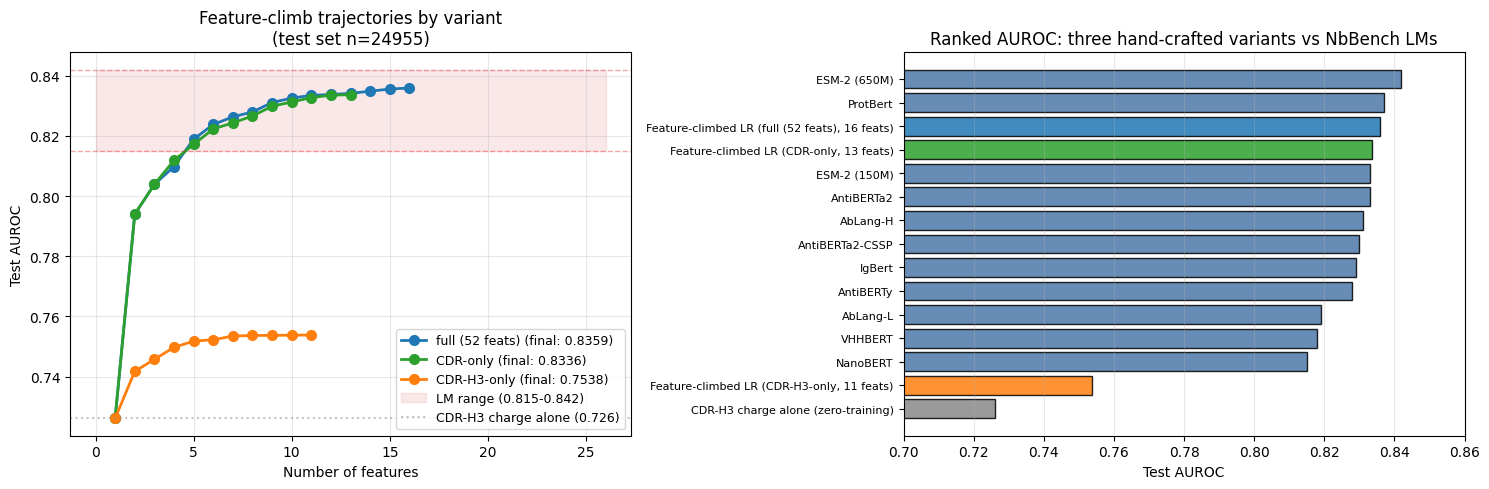

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
colors = {'full (52 feats)': '#1f77b4', 'CDR-only': '#2ca02c', 'CDR-H3-only': '#ff7f0e'}
for tag, res in all_results.items():
    df = res['climb_df']
    ax.plot(df['n_features'], df['test_AUROC'], 'o-', linewidth=2, markersize=7,
             color=colors[tag], label=f'{tag} (final: {final_results[tag]["test_AUROC"]:.4f})')

# LM reference bands
ax.fill_between([0, MAX_FEATURES + 1], 0.815, 0.842, alpha=0.1, color='#d62728',
                 label='LM range (0.815-0.842)')
ax.axhline(0.842, color='#d62728', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(0.815, color='#d62728', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(0.7262, color='#888888', linestyle=':', alpha=0.5, label='CDR-H3 charge alone (0.726)')

ax.set_xlabel('Number of features')
ax.set_ylabel('Test AUROC')
ax.set_title(f'Feature-climb trajectories by variant\n(test set n={len(X_test_full)})')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Right: comparison bars showing all three variants + LMs
ax = axes[1]
top_n = 17
sub = comparison.head(top_n).iloc[::-1]
def _color(m):
    if 'charge alone' in m: return '#888888'
    if 'CDR-only' in m: return '#2ca02c'
    if 'CDR-H3-only' in m: return '#ff7f0e'
    if 'full (52 feats)' in m or 'full (52' in m: return '#1f77b4'
    return '#4c78a8'  # language models in a neutral blue-gray
colors_bars = [_color(m) for m in sub['model']]
ax.barh(range(len(sub)), sub['AUROC'], color=colors_bars, alpha=0.85, edgecolor='black')
ax.set_yticks(range(len(sub)))
ax.set_yticklabels(sub['model'], fontsize=8)
ax.set_xlim(0.70, 0.86)
ax.set_xlabel('Test AUROC')
ax.set_title('Ranked AUROC: three hand-crafted variants vs NbBench LMs')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT / 'three_variant_climb.png', dpi=150, bbox_inches='tight')
plt.show()

## §8. Save summary

In [ ]:
summary = {
    'version': PROJECT_VERSION,
    'dataset': 'ZYMScott/polyreaction (NbBench PolyRx)',
    'train_n': int(len(X_train_full)),
    'val_n': int(len(X_val_full)),
    'test_n': int(len(X_test_full)),
    'variants': {
        tag: {
            'candidate_pool_size': len(pool),
            'selected_features': final_results[tag]['selected'],
            'n_selected': final_results[tag]['n_features'],
            'test_AUROC': final_results[tag]['test_AUROC'],
            'test_AUROC_95ci': final_results[tag]['test_AUROC_95ci'],
            'test_AUPRC': final_results[tag]['test_AUPRC'],
            'coefficients': final_results[tag]['coefficients'],
            'climb_history': all_results[tag]['climb_df'].to_dict(orient='records'),
        }
        for tag, pool in variants.items()
    },
    'nbbench_lm_range': {'best': 0.842, 'worst': 0.815},
}
with open(DRIVE_OUTPUT / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("Outputs saved to:", DRIVE_OUTPUT)
print()
print("=" * 80)
print("HEADLINE SUMMARY")
print("=" * 80)
print(f"{'Variant':<20}{'# feats':>10}{'Test AUROC':>14}{'95% CI':>22}{'LMs beaten':>14}")
print('-' * 80)
for tag, res in final_results.items():
    ci_lo, ci_hi = res['test_AUROC_95ci']
    ci_str = f'[{ci_lo:.4f}, {ci_hi:.4f}]'
    n_lms_beaten = sum(1 for auc in nbbench_table10.values() if auc < res['test_AUROC'])
    print(f"{tag:<20}{res['n_features']:>10}{res['test_AUROC']:>14.4f}{ci_str:>22}{n_lms_beaten:>10}/11")

Outputs saved to: /content/drive/MyDrive/PolyAtlas/PolyAtlas_05h_cdr_only_climb_v0.1.0

HEADLINE SUMMARY
Variant                # feats    Test AUROC                95% CI    LMs beaten
--------------------------------------------------------------------------------
full (52 feats)             16        0.8359      [0.8308, 0.8410]         9/11
CDR-only                    13        0.8336      [0.8281, 0.8389]         9/11
CDR-H3-only                 11        0.7538      [0.7476, 0.7600]         0/11
